## Modified introduction using forex data

This is the trading rule example shown in [the introduction](https://github.com/pst-group/pysystemtrade/blob/master/docs/introduction.md) but modified to use Interactive Brokers instead of CSV files as data source.

IB requires a minimum equity and a monthly subscription to provide historical data on future contracts.  This example was modified to use FX prices instead futures to make it runnable with free unfunded paper trading accounts.  Note that Rob [does not recommend trading FX spot data with IB due to their high fees](https://github.com/pst-group/pysystemtrade/issues/517#issuecomment-1010770678).

First, import the required packages and initialize ib_insync.  

In [3]:
from sysbrokers.IB.ib_connection import connectionIB
from sysbrokers.IB.ib_Fx_prices_data import ibFxPricesData

from ib_async import util
util.startLoop() #only required when running inside a notebook

Connecting to Interactive Brokers gateway...

In [8]:
conn = connectionIB(111)
conn

2026-09-05 20:47:52 ERROR connectionIB {'type': 'connectionIB', 'broker': 'IB', 'clientid': 111} Broker account ID not found in private config - may cause issues
2026-09-05 20:47:53 WARNING ib_async.wrapper Warning 2104, reqId -1: Market data farm connection is OK:usfarm.nj
2026-09-05 20:47:53 WARNING ib_async.wrapper Warning 2104, reqId -1: Market data farm connection is OK:hfarm
2026-09-05 20:47:53 WARNING ib_async.wrapper Warning 2104, reqId -1: Market data farm connection is OK:usopt.nj
2026-09-05 20:47:53 WARNING ib_async.wrapper Warning 2104, reqId -1: Market data farm connection is OK:usfarm
2026-09-05 20:47:53 WARNING ib_async.wrapper Warning 2106, reqId -1: HMDS data farm connection is OK:apachmds
2026-09-05 20:47:53 WARNING ib_async.wrapper Warning 2106, reqId -1: HMDS data farm connection is OK:ushmds
2026-09-05 20:47:53 WARNING ib_async.wrapper Warning 2158, reqId -1: Sec-def data farm connection is OK:secdefhk


IB broker connection{'ipaddress': '127.0.0.1', 'port': 4001, 'client': 111}

2026-09-05 20:48:18 WARNING ib_async.wrapper Warning 2105, reqId -1: HMDS data farm connection is broken:apachmds
2026-09-05 20:48:18 WARNING ib_async.wrapper Warning 2106, reqId -1: HMDS data farm connection is OK:apachmds
2026-09-05 20:48:18 WARNING ib_async.wrapper Warning 2103, reqId -1: Market data farm connection is broken:hfarm
2026-09-05 20:48:18 WARNING ib_async.wrapper Warning 2104, reqId -1: Market data farm connection is OK:hfarm
2026-09-05 20:49:10 WARNING ib_async.wrapper Warning 2108, reqId -1: Market data farm connection is inactive but should be available upon demand.usfarm.nj
2026-09-05 20:49:10 WARNING ib_async.wrapper Warning 2108, reqId -1: Market data farm connection is inactive but should be available upon demand.usfarm.nj
2026-09-05 20:49:12 WARNING ib_async.wrapper Warning 2104, reqId -1: Market data farm connection is OK:usfarm.nj
2026-09-05 20:52:52 WARNING ib_async.wrapper Warning 2108, reqId -1: Market data farm connection is inactive but should be availabl

See what fx instruments we have configured.  These are configured in `sysbrokers/IB/ib_config_spot_FX.csv`

In [10]:
from sysdata.data_blob import dataBlob

data = dataBlob(ib_conn=conn)
ibfxpricedata = ibFxPricesData(conn, data)
ibfxpricedata.get_list_of_fxcodes()


['AUDUSD',
 'CADUSD',
 'CHFUSD',
 'EURUSD',
 'GBPUSD',
 'HKDUSD',
 'JPYUSD',
 'KRWUSD',
 'CNHUSD',
 'SGDUSD',
 'MXPUSD',
 'SEKUSD']

Now we select one instrument (`EURUSD`) and try to fetch historical data for it.

In [11]:
ibfxpricedata.get_fx_prices('EURUSD')

2026-09-05 20:57:00 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Updating log attributes
2026-09-05 20:57:04 DEBUG ibFxPricesData Log attributes reset
2026-09-05 20:57:04 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Downloaded 259 prices


index
2025-09-05 23:00:00    1.17160
2025-09-08 23:00:00    1.17635
2025-09-09 23:00:00    1.17085
2025-09-10 23:00:00    1.16950
2025-09-11 23:00:00    1.17340
                        ...   
2026-08-31 23:00:00    1.16180
2026-09-01 23:00:00    1.15930
2026-09-02 23:00:00    1.15885
2026-09-03 23:00:00    1.16260
2026-09-04 23:00:00    1.16145
Name: FINAL, Length: 259, dtype: float64

Data can also be indexed as a python dict:

In [12]:
ibfxpricedata['JPYUSD']

2026-09-05 20:57:22 DEBUG ibFxPricesData {'currency_code': 'USDJPY'} Updating log attributes
2026-09-05 20:57:24 DEBUG ibFxPricesData Log attributes reset
2026-09-05 20:57:24 DEBUG ibFxPricesData {'currency_code': 'JPYUSD'} Downloaded 259 prices


index
2025-09-05 23:00:00    0.006783
2025-09-08 23:00:00    0.006779
2025-09-09 23:00:00    0.006784
2025-09-10 23:00:00    0.006781
2025-09-11 23:00:00    0.006793
                         ...   
2026-08-31 23:00:00    0.006260
2026-09-01 23:00:00    0.006243
2026-09-02 23:00:00    0.006301
2026-09-03 23:00:00    0.006418
2026-09-04 23:00:00    0.006400
Name: FINAL, Length: 259, dtype: float64

Create the trading rule

In [13]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc


def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    Calculate the ewmac trading rule forecast, given a price and EWMA speeds Lfast, Lslow and vol_lookback

    """
    if Lslow is None:
        Lslow = 4 * Lfast

    ## We don't need to calculate the decay parameter, just use the span directly
    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma

    vol = robust_vol_calc(price.diff())

    return raw_ewmac / vol

Run a forecast with the previous rule

In [14]:
price=ibfxpricedata['EURUSD']
ewmac=calc_ewmac_forecast(price, 32, 128)
ewmac.tail(5)

2026-09-05 20:57:59 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Updating log attributes
2026-09-05 20:58:00 DEBUG ibFxPricesData Log attributes reset
2026-09-05 20:58:00 DEBUG ibFxPricesData {'currency_code': 'EURUSD'} Downloaded 259 prices


index
2026-08-31 23:00:00   -0.195525
2026-09-01 23:00:00   -0.159524
2026-09-02 23:00:00   -0.133699
2026-09-03 23:00:00   -0.055499
2026-09-04 23:00:00    0.001245
Name: FINAL, dtype: float64

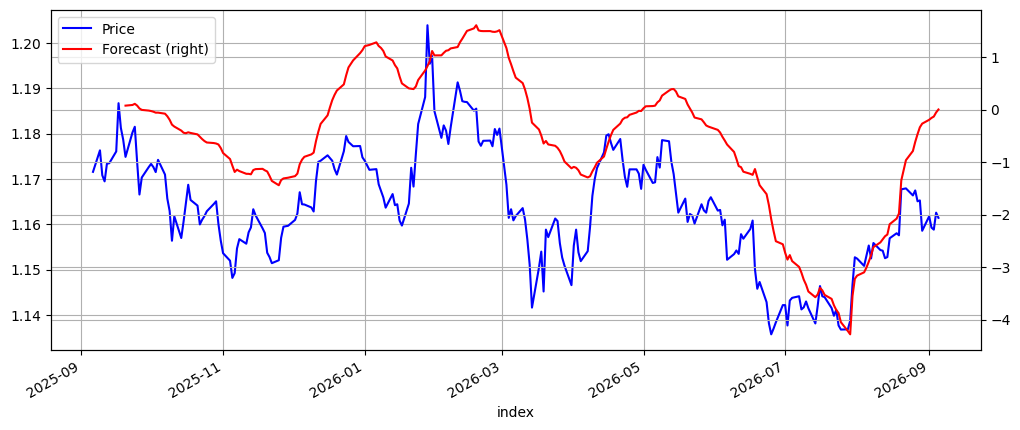

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

ax1 = price.plot(color='blue', grid=True, label='Price')
ax2 = ewmac.plot(color='red', grid=True, secondary_y=True, label='Forecast')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()


plt.legend(h1+h2, l1+l2, loc=2)
plt.show()

The original introduction jumps directly to "Did we make any money?".  
I would like to see here the orders that were triggered by this forecast, but instead we jump directly into P&L.  Still, these are the P&L numbers for this forecast and data:

In [16]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast = ewmac, price = price)
account.percent.stats()

[[('min', '-1.137'),
  ('max', '0.4013'),
  ('median', '-0.0008329'),
  ('mean', '-0.01839'),
  ('std', '0.1464'),
  ('skew', '-2.932'),
  ('ann_mean', '-4.708'),
  ('ann_std', '2.342'),
  ('sharpe', '-2.01'),
  ('sortino', '-1.886'),
  ('avg_drawdown', '-1.808'),
  ('time_in_drawdown', '0.9234'),
  ('calmar', '-0.9063'),
  ('avg_return_to_drawdown', '-2.603'),
  ('avg_loss', '-0.09419'),
  ('avg_gain', '0.06755'),
  ('gaintolossratio', '0.7172'),
  ('profitfactor', '0.6139'),
  ('hitrate', '0.4612'),
  ('t_stat', '-2.03'),
  ('p_value', '0.04342')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

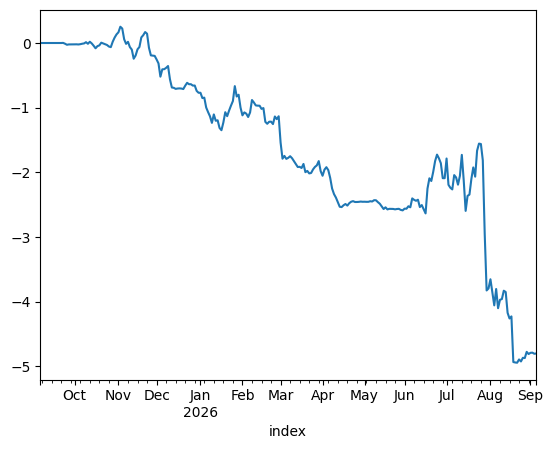

In [17]:
account.curve().plot()
plt.show()

In [18]:
conn.close_connection()

2026-09-05 21:00:45 DEBUG connectionIB {'type': 'connectionIB', 'broker': 'IB', 'clientid': 111} Terminating {'ipaddress': '127.0.0.1', 'port': 4001, 'client': 111}
